Compute an anndata object from MTX files.
Filter, normalize, reduce

In [52]:
# 1. ALign sequences using STAR command: 
# /sps/lbmc/ogandril/STAR/source/STAR   --runThreadN 16   --genomeDir /sps/lbmc/ogandril/genomeDir  --readFilesCommand gunzip -c -c --readFilesIn /sps/lbmc/ogandril/OG3579/Projet_50_25/Fastq_files/Lib_Ev226_Asteria_S1_R2_001.fastq.gz /sps/lbmc/ogandril/OG3579/Projet_50_25/Fastq_files/Lib_Ev226_Asteria_S1_R1_001.fastq.gz --outFileNamePrefix OG3579_   --outSAMtype BAM   SortedByCoordinate --outSAMattributes NH   HI   nM   AS   CR   UR   CB   UB   GX   GN   sS   sQ sM --outSAMunmapped Within      --sjdbGTFfile /sps/lbmc/ogandril/Homo_sapiens.GRCh38.99.chr.gtf   --soloType CB_UMI_Simple --soloCBstart 1   --soloUMIstart 13   --soloCBlen 12   --soloUMIlen 13 --soloBarcodeReadLength 1   --soloCBwhitelist /sps/lbmc/ogandril/OG3568/white_list.tsv      --soloFeatures Gene Velocyto --soloUMIdedup 1MM_CR      --soloCBmatchWLtype Exact
# Generates three files: matrix.mtx, barcodes.tsv and features.tsv

In [53]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sbn
import scipy
import anndata as ad
import scanpy as sc
import scipy.stats as stats
import ot 
from scipy.stats import wasserstein_distance
import math
from numpy.linalg import pinv
import random
from anndata import AnnData 
from scipy.cluster.hierarchy import linkage, to_tree, dendrogram
from scipy.spatial.distance import pdist
import scvelo as scv
from scipy import sparse
import cellrank as cr
import scFates as scf

In [54]:
# Hyperparameter values

# Used to filter 
min_genes=100
min_cells=3
n_top_genes=2000

# Used for dimensionality reduction
rs=10
resolution=0.5
random.seed(rs)

1. Create the Anndata objects

In [55]:
path = "/Users/olivier_2/Documents/En_cours/Labo/Manipes/OG3579/OG3579_Solo.out/"

# 1. Load main Matrix
X = sc.read_mtx(path + 'Gene/filtered/matrix.mtx')
X = X.X.transpose()

if np.all(X.data % 1 == 0):
    X = X.astype(np.int32) 
else:
    print("Main matrix contains decimal values.")
# --------------------


# 2. Load Velocyto data (Spliced, Unspliced, Ambiguous)
mtxU = np.loadtxt(path + 'Velocyto/filtered/unspliced.mtx', skiprows=3, delimiter=' ')

shapeU = np.loadtxt(path + 'Velocyto/filtered/unspliced.mtx', skiprows=2, max_rows=1, delimiter=' ')[0:2].astype(int)
shapeS = np.loadtxt(path + 'Velocyto/filtered/spliced.mtx', skiprows=2, max_rows=1, delimiter=' ')[0:2].astype(int)
shapeA = np.loadtxt(path + 'Velocyto/filtered/ambiguous.mtx', skiprows=2, max_rows=1, delimiter=' ')[0:2].astype(int)

mtxU = np.loadtxt(path + 'Velocyto/filtered/unspliced.mtx', skiprows=3, delimiter=' ', dtype=int)
mtxS = np.loadtxt(path + 'Velocyto/filtered/spliced.mtx', skiprows=3, delimiter=' ', dtype=int)
mtxA = np.loadtxt(path + 'Velocyto/filtered/ambiguous.mtx', skiprows=3, delimiter=' ', dtype=int)

spliced = sparse.csr_matrix((mtxS[:, 2], (mtxS[:, 0]-1, mtxS[:, 1]-1)), shape=shapeS).transpose()
unspliced = sparse.csr_matrix((mtxU[:, 2], (mtxU[:, 0]-1, mtxU[:, 1]-1)), shape=shapeU).transpose()
ambiguous = sparse.csr_matrix((mtxA[:, 2], (mtxA[:, 0]-1, mtxA[:, 1]-1)), shape=shapeA).transpose()

# 3. Load metadata
obs = pd.read_csv(path + 'Velocyto/filtered/barcodes.tsv', header=None, index_col=0)
obs.index.name = None

var = pd.read_csv(path + 'Velocyto/filtered/features.tsv', sep='\t',
                  names=('gene_ids', 'feature_types'), index_col=1)

if var.index.duplicated().any():
    print(f"Duplicates detected: {var.index.duplicated().sum()}. Fixing...")
    
    new_index = []
    seen_counts = {}
    
    for name in var.index:
        if name in seen_counts:
            seen_counts[name] += 1
            new_index.append(f"{name}-{seen_counts[name]}")
        else:
            seen_counts[name] = 0
            new_index.append(name)
            
    var.index = new_index
    print("Gene names made unique successfully.")

# 4. Create AnnData object
adata = ad.AnnData(X=X, obs=obs, var=var,
                   layers={'spliced': spliced, 'unspliced': unspliced, 'ambiguous': ambiguous})

# 5. Filter barcodes
selected_barcodes = pd.read_csv(path + 'Gene/filtered/barcodes.tsv', header=None)[0]

# Safety check: Ensure selected barcodes exist in the Velocyto object
valid_barcodes = [b for b in selected_barcodes.values if b in adata.obs_names]

if len(valid_barcodes) != len(selected_barcodes):
    print(f"Warning: {len(selected_barcodes) - len(valid_barcodes)} barcodes not found in Velocyto object.")

# Subset and explicitly copy to avoid "view" warnings later
adata = adata[valid_barcodes].copy()

adata.write_h5ad('adata_EV226.h5ad')

Duplicates detected: 34. Fixing...
Gene names made unique successfully.


In [56]:
path="/Users/olivier_2/Documents/En_cours/Labo/Manipes/OG3568/"

# 1. Load main Matrix
X = sc.read_mtx(path + 'Gene/filtered/matrix.mtx')
X = X.X.transpose()

if np.all(X.data % 1 == 0):
    X = X.astype(np.int32) 
else:
    print("Warning: Main matrix contains decimal values.")
# --------------------

# 2. Load Velocyto data (Spliced, Unspliced, Ambiguous)
mtxU = np.loadtxt(path + 'Velocyto/filtered/unspliced.mtx', skiprows=3, delimiter=' ')

shapeU = np.loadtxt(path + 'Velocyto/filtered/unspliced.mtx', skiprows=2, max_rows=1, delimiter=' ')[0:2].astype(int)
shapeS = np.loadtxt(path + 'Velocyto/filtered/spliced.mtx', skiprows=2, max_rows=1, delimiter=' ')[0:2].astype(int)
shapeA = np.loadtxt(path + 'Velocyto/filtered/ambiguous.mtx', skiprows=2, max_rows=1, delimiter=' ')[0:2].astype(int)

# Lecture des données AVEC dtype=int
mtxU = np.loadtxt(path + 'Velocyto/filtered/unspliced.mtx', skiprows=3, delimiter=' ', dtype=int)
mtxS = np.loadtxt(path + 'Velocyto/filtered/spliced.mtx', skiprows=3, delimiter=' ', dtype=int)
mtxA = np.loadtxt(path + 'Velocyto/filtered/ambiguous.mtx', skiprows=3, delimiter=' ', dtype=int)

# Création des matrices (seront maintenant automatiquement en int)
spliced = sparse.csr_matrix((mtxS[:, 2], (mtxS[:, 0]-1, mtxS[:, 1]-1)), shape=shapeS).transpose()
unspliced = sparse.csr_matrix((mtxU[:, 2], (mtxU[:, 0]-1, mtxU[:, 1]-1)), shape=shapeU).transpose()
ambiguous = sparse.csr_matrix((mtxA[:, 2], (mtxA[:, 0]-1, mtxA[:, 1]-1)), shape=shapeA).transpose()

# 3. Load metadata
obs = pd.read_csv(path + 'Velocyto/filtered/barcodes.tsv', header=None, index_col=0)
obs.index.name = None

var = pd.read_csv(path + 'Velocyto/filtered/features.tsv', sep='\t',
                  names=('gene_ids', 'feature_types'), index_col=1)

if var.index.duplicated().any():
    print(f"Duplicates detected: {var.index.duplicated().sum()}. Fixing...")
    
    new_index = []
    seen_counts = {}
    
    for name in var.index:
        if name in seen_counts:
            seen_counts[name] += 1
            new_index.append(f"{name}-{seen_counts[name]}")
        else:
            seen_counts[name] = 0
            new_index.append(name)
            
    var.index = new_index
    print("Gene names made unique successfully.")

# 4. Create AnnData object
adata = ad.AnnData(X=X, obs=obs, var=var,
                   layers={'spliced': spliced, 'unspliced': unspliced, 'ambiguous': ambiguous})

# 5. Filter barcodes
selected_barcodes = pd.read_csv(path + 'Gene/filtered/barcodes.tsv', header=None)[0]

# Safety check: Ensure selected barcodes exist in the Velocyto object
valid_barcodes = [b for b in selected_barcodes.values if b in adata.obs_names]

if len(valid_barcodes) != len(selected_barcodes):
    print(f"Warning: {len(selected_barcodes) - len(valid_barcodes)} barcodes not found in Velocyto object.")

# Subset and explicitly copy to avoid "view" warnings later
adata = adata[valid_barcodes].copy()

adata.write_h5ad('adata_EV126.h5ad')

Duplicates detected: 34. Fixing...
Gene names made unique successfully.


In [57]:
print('Loading')
adata_126 = ad.read_h5ad('adata_EV126.h5ad')
adata_226 = ad.read_h5ad('adata_EV226.h5ad')

print('Merge')
adata=adata_126.concatenate(adata_226, batch_key='Sample')
adata.write_h5ad('merged_126_226.h5ad')

print(f"Matrix shape: {adata.shape[0]} cells x {adata.shape[1]} genes")

Loading
Merge
Matrix shape: 4345 cells x 60617 genes


2. Filter, normalize, reduce

In [58]:
# Filter
sc.pp.filter_cells(adata, min_genes=min_genes)
sc.pp.filter_genes(adata, min_cells=min_cells)

# Normalize
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=n_top_genes)

# Dimensionality reduction
sc.tl.pca(adata)
sc.pp.neighbors(adata, n_neighbors=20, n_pcs=40)
sc.tl.louvain(adata, resolution=resolution)
sc.tl.umap(adata)


3. Explore data structure 

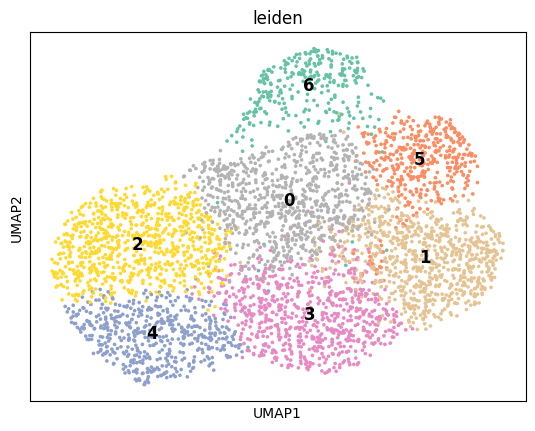

In [59]:
# Cluster cells
sc.tl.leiden(adata, resolution=0.6, key_added='leiden')

ax = sc.pl.umap(
    adata,
    color='leiden',
    use_raw=False,
    legend_fontsize=12,
    palette='Set2_r',
    legend_loc='on data',
    frameon=True,
    show=False  
)

plt.show()

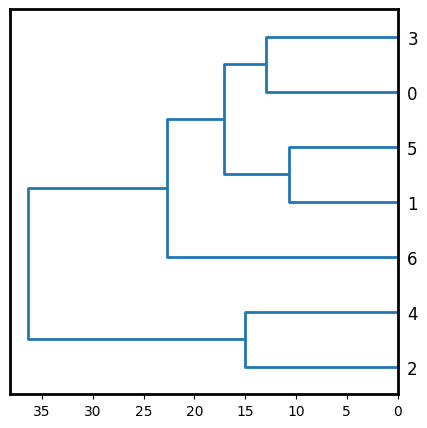

In [60]:
# Calculate mean gene expression for each cluster
cluster_means = np.array([adata[adata.obs["leiden"] == cluster].X.toarray().mean(axis=0)
                         for cluster in adata.obs["leiden"].cat.categories])

# Calculate the distance matrix
distance_matrix = pdist(cluster_means, metric='euclidean')

# Recalculate the linkage matrix
linkage_matrix = linkage(distance_matrix, method='ward')

# Use categories as labels
labels = adata.obs["leiden"].cat.categories.tolist()
plt.figure(figsize=(5, 5))
dendro = dendrogram(linkage_matrix, labels=labels, orientation='left', color_threshold=0)

# Iterate over all lines in the dendrogram and make them thicker
for obj in plt.gca().get_children():
    # If it's a LineCollection (typical for dendrogram branches)
    if hasattr(obj, 'set_linewidth'):
        obj.set_linewidth(2)  
    # If it's a Line2D object
    elif isinstance(obj, plt.Line2D):
        obj.set_linewidth(10)

plt.savefig('dendrogramme.svg', format='svg', bbox_inches='tight', dpi=300)

plt.show()

4. Define cell types

In [61]:
new_names = {
    '0': 'Transit_cells',
    '1': 'Diff_cells',
    '2': 'Stem_cells',
    '3': 'Transit_cells',
    '4': 'Stem_cells',
    '5': 'Diff_cells',
    '6': 'Transit_cells',
    '7': 'Transit_cells'
}

adata.obs['cell_type'] = adata.obs['leiden'].map(new_names)

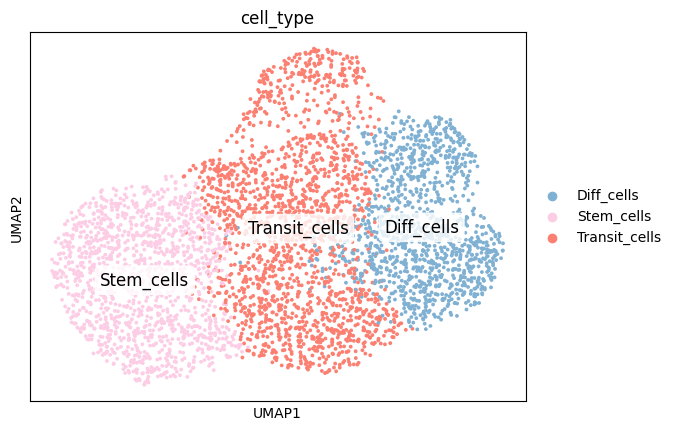

In [62]:
# Get the 'Set3' colormap
cmap = plt.get_cmap('Set3')
# Reorganize colors if necessary (selecting specific indices: 4, 7, 3)
couleurs = [cmap(4), cmap(7), cmap(3)]       

# Plot the UMAP graph
ax = sc.pl.umap(
    adata,
    color='cell_type',
    use_raw=False,
    palette=couleurs,
    frameon=True,
    size=30,
    show=False  # Disable automatic display
)

# Retrieve UMAP point coordinates
umap_coords = adata.obsm['X_umap']

# Iterate over each cell type and add a white box around the annotations
for cell_type in adata.obs['cell_type'].unique():
    # Filter coordinates for cells of this type
    cell_indices = adata.obs['cell_type'] == cell_type
    cell_coords = umap_coords[cell_indices]

    # Calculate the mean position to place the annotation
    mean_x, mean_y = np.mean(cell_coords, axis=0)

    # Add an annotation with a white box
    ax.annotate(
        cell_type,
        xy=(mean_x, mean_y),
        fontsize=12,
        color='black',
        ha='center',
        va='center',
        bbox=dict(
            boxstyle='round,pad=0.3',
            facecolor='white',  # White background
            edgecolor='white',  # White border
            alpha=0.8  # Transparency
        )
    )

# Save the plot as SVG
plt.savefig(
    "umap_cell_types_avec_cadre_labels.svg",
    format='svg',
    bbox_inches='tight',
    dpi=300
)

5. Plot gene expression

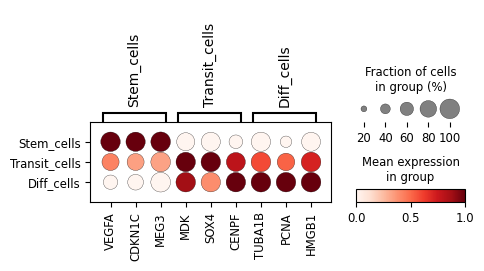

In [68]:
# Plot Cell types signatures
# Run twice to get the correct order of the cell types in the dotplot

sc.tl.rank_genes_groups(adata, groupby='cell_type', key_added='rank_genes')

df_diff= sc.get.rank_genes_groups_df(adata, group="Diff_cells",key='rank_genes')
df_stem= sc.get.rank_genes_groups_df(adata, group="Stem_cells",key='rank_genes')
df_transit = sc.get.rank_genes_groups_df(adata, group="Transit_cells",key='rank_genes')

diff_genes_3=df_diff['names'].head(3)
stem_genes_3=df_stem['names'].head(3)
transit_genes_3=df_transit['names'].head(3)

all_genes_3=diff_genes_3.tolist() + stem_genes_3.tolist() + transit_genes_3.tolist()

# Define cell type order
order = ["Stem_cells", "Transit_cells", "Diff_cells"]

# Convert 'cell_type' to a categorical variable with the specified order
adata.obs['cell_type'] = pd.Categorical(
    adata.obs['cell_type'],
    categories=order,
    ordered=True
)

sc.pl.rank_genes_groups_dotplot(
    adata,
    groupby="cell_type",
    standard_scale="var",
    n_genes=3, 
    dendrogram=False, 
    key='rank_genes'
)



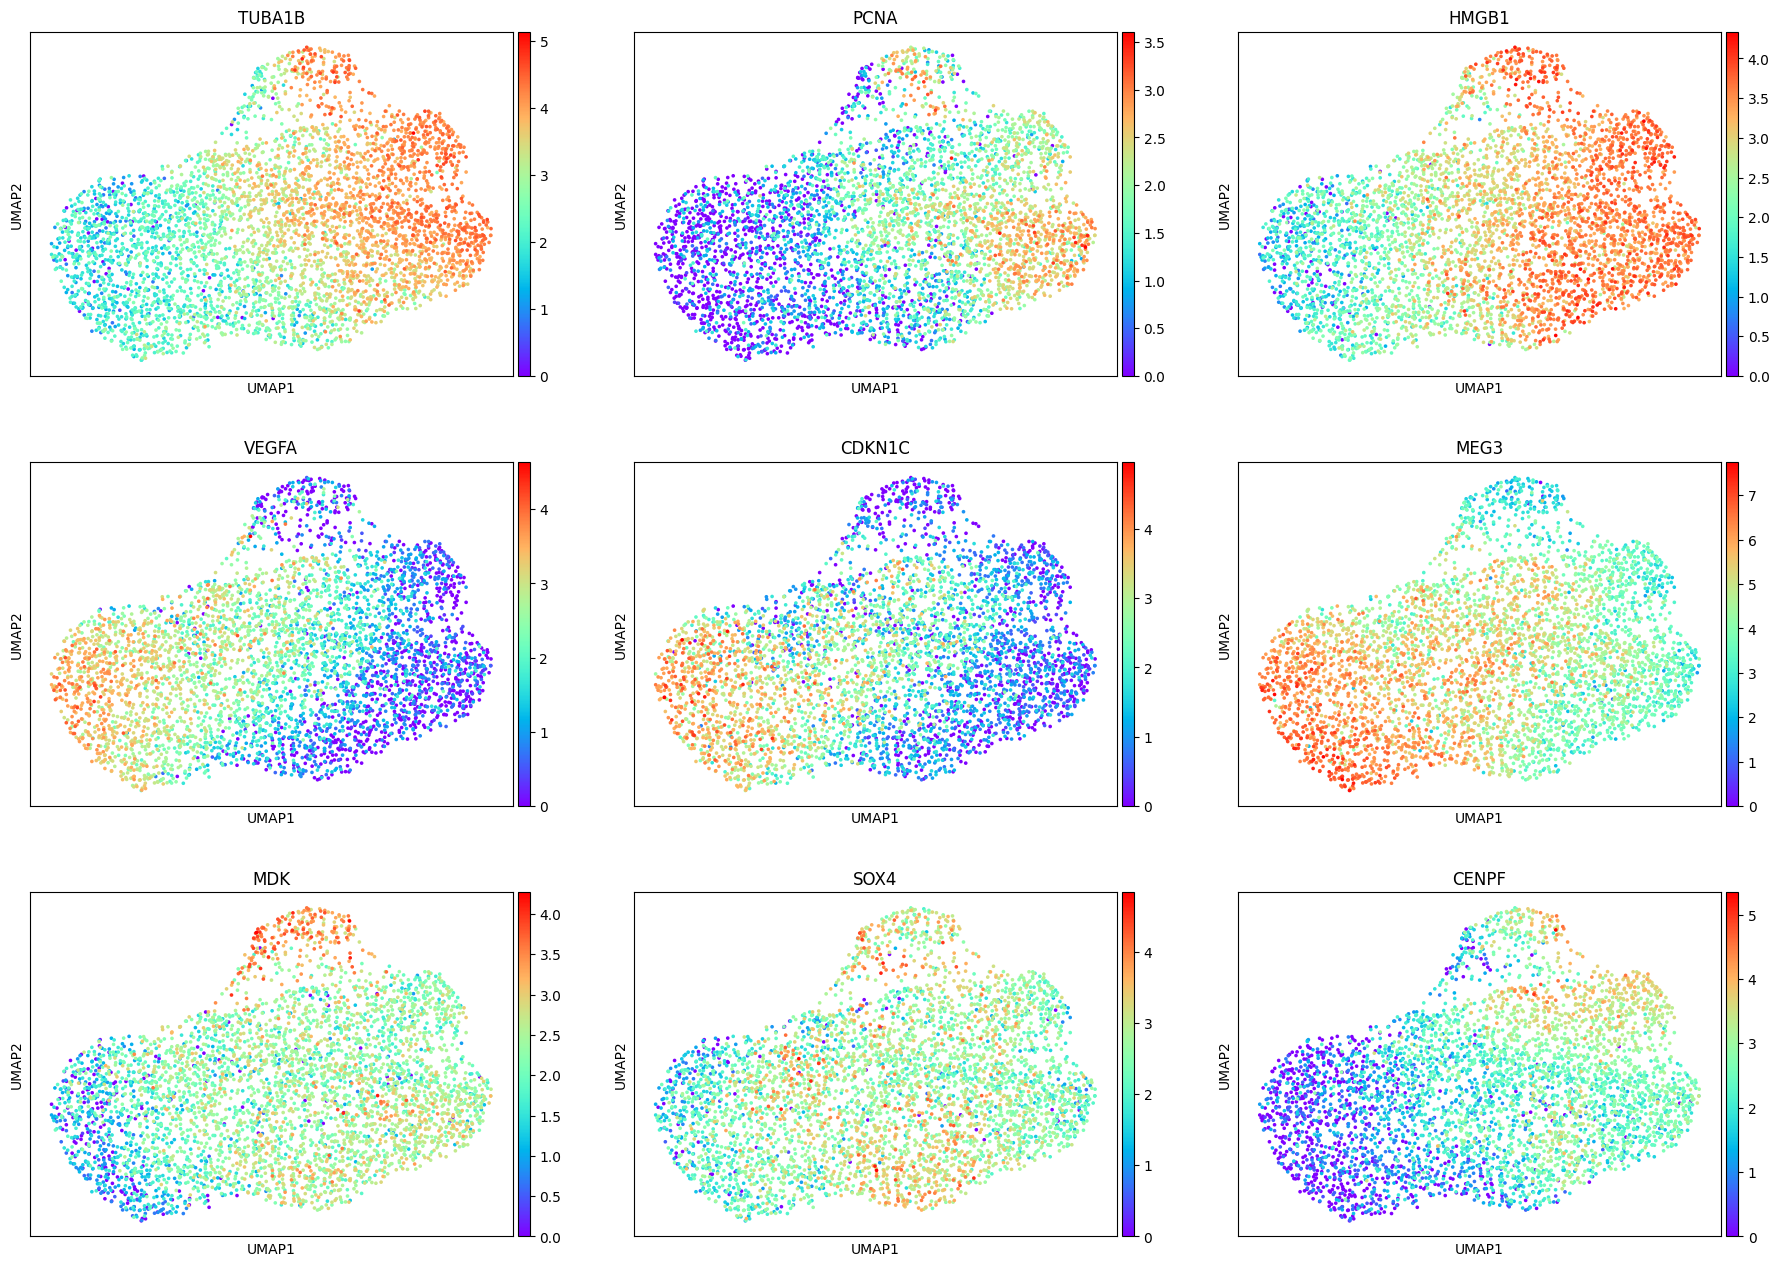

In [69]:
# Plot the UMAP graph with gene expression
sc.pl.umap(
    adata,
    color=all_genes_3,
    use_raw=False,
    cmap='rainbow',
    frameon=True,
    show=True,
    ncols=3   
)

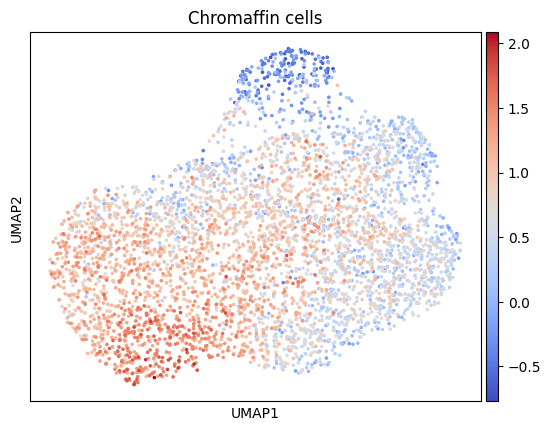

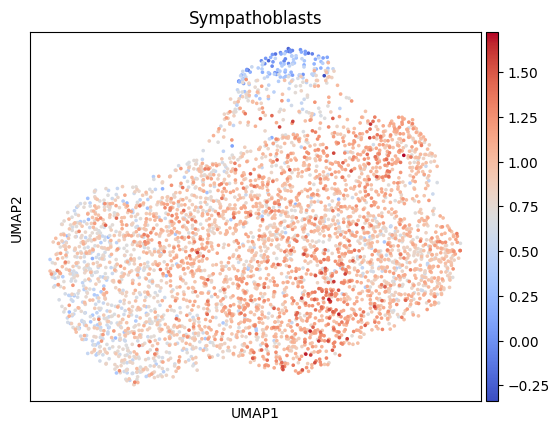

In [65]:
# Plot gene signatures for chromaffin cells and sympathoblasts

gene_list_1 = ['TH', 'PENK', 'CHGA', 'CHGB', 'DGKK', 'DLK1','EPAS1']

gene_list_2 = ['ISL1', 'NEFM', 'NEFL', 'STMN2', 'ELAVL2', 'ELAVL4','CARTPT', 'PRPH', 'LIX1', 'CPLX1', 'EGLN3']

sc.tl.score_genes(adata, gene_list_1, score_name='Chromaffin cells')
sc.pl.umap(adata, color='Chromaffin cells', cmap='coolwarm', save="Chromaffin_cells.svg")

sc.tl.score_genes(adata, gene_list_2, score_name='Sympathoblasts')
sc.pl.umap(adata, color='Sympathoblasts', cmap='coolwarm', save="Sympathoblasts.svg")

calculating cell cycle phase
-->     'S_score' and 'G2M_score', scores of cell cycle phases (adata.obs)


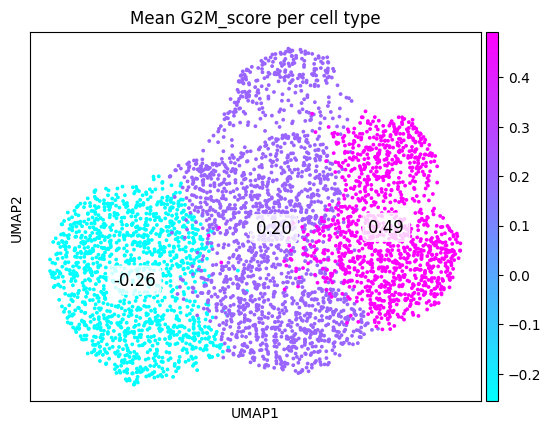

In [66]:
# Plot cell cycle

scv.tl.score_genes_cell_cycle(adata)

# Compute the mean G2_score per cell type 
cell_type_G2_score_mean = adata.obs.groupby('cell_type')['G2M_score'].mean()
# Create a new column in adata.obs to store the mean pseudotime per cell
adata.obs['cell_type_G2_score_mean'] = adata.obs['cell_type'].map(cell_type_G2_score_mean)
adata.obs['cell_type_G2_score_mean'] = pd.to_numeric(adata.obs['cell_type_G2_score_mean'], errors='coerce')

# Plot the UMAP
sc.pl.umap(
    adata,
    color='cell_type_G2_score_mean',
    color_map='cool',
    legend_loc='on data',
    frameon=True,
    size=30,
    title='Mean G2M_score per cell type',
    show=False, 
)

# Get the current axis
ax = plt.gca()

# Get centroid positions for each cell type
centroids = {}
for cell_type, group in adata.obs.groupby('cell_type'):
    # Convert indices to numerical positions
    indices = [np.where(adata.obs.index == idx)[0][0] for idx in group.index]
    centroids[cell_type] = np.mean(adata.obsm['X_umap'][indices, :], axis=0)


# Add annotations for each cell type with rounded values
for cell_type, (x, y) in centroids.items():
    mean_G2 = adata.obs[adata.obs['cell_type'] == cell_type]['cell_type_G2_score_mean'].mean()
    ax.annotate(f"{mean_G2:.2f}", xy=(x, y), fontsize=12, color='black', ha='center', va='center', 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='white', alpha=0.8))


# Display the plot
plt.show()

6. Save anndata object.

In [67]:
adata.write_h5ad('adata_3700_1.h5ad')